## 多项式回归

In [1]:
import math
import numpy as np
import torch
from torch import nn
from d2l import d2l_torch as d2l

### 生成数据集

给定$x$，我们将[**使用以下三阶多项式来生成训练和测试数据的标签：**]

(**$$y = 5 + 1.2x - 3.4\frac{x^2}{2!} + 5.6 \frac{x^3}{3!} + \epsilon \text{ where }
\epsilon \sim \mathcal{N}(0, 0.1^2).$$**)

噪声项$\epsilon$服从均值为0且标准差为0.1的正态分布。
在优化的过程中，我们通常希望避免非常大的梯度值或损失值。
这就是我们将特征从$x^i$调整为$\frac{x^i}{i!}$的原因，
这样可以避免很大的$i$带来的特别大的指数值。
我们将为训练集和测试集各生成100个样本。

In [2]:
max_degree = 20                 # 多项式的最大阶数
n_train, n_test = 100, 100      # 训练
true_w = np.zeros(max_degree)   # 分配大量的空间
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

generator = np.random.default_rng(7)
features = generator.normal(size=(n_train + n_test, 1))     # 生成形状为[200, 1]的随机数组，均值为0，标准差为1
generator.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)
# labels 的维度: (n_train + n_test,)
labels = np.dot(poly_features, true_w)
labels += generator.normal(scale=0.1, size=labels.shape)

In [3]:
# Numpy ndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32) for x in [true_w, features, poly_features, labels]]

In [4]:
features[:2], poly_features[:2, :], labels[:2]

(tensor([[ 0.2713],
         [-0.1117]]),
 tensor([[ 1.0000e+00,  2.7126e-01,  3.6792e-02,  3.3268e-03,  2.2561e-04,
           1.2240e-05,  5.5338e-07,  2.1445e-08,  7.2715e-10,  2.1917e-11,
           5.9452e-13,  1.4661e-14,  3.3142e-16,  6.9155e-18,  1.3400e-19,
           2.4232e-21,  4.1083e-23,  6.5555e-25,  9.8793e-27,  1.4105e-28],
         [ 1.0000e+00, -1.1170e-01,  6.2387e-03, -2.3229e-04,  6.4868e-06,
          -1.4492e-07,  2.6979e-09, -4.3052e-11,  6.0113e-13, -7.4608e-15,
           8.3338e-17, -8.4628e-19,  7.8776e-21, -6.7688e-23,  5.4006e-25,
          -4.0217e-27,  2.8077e-29, -1.8449e-31,  1.1449e-33, -6.7307e-36]]),
 tensor([5.1536, 4.8476]))

### 对模型进行训练和测试

In [5]:
def evaluate_loss(net, data_iter, loss):
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)     # 损失的总和，样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

In [6]:
def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)), batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01, momentum=0.0, weight_decay=0.0)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log', xlim=[1, num_epochs], ylim=[1e-3, 1e2], legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss), evaluate_loss(net, test_iter, loss)))

    print('weight: ', net[0].weight.data.numpy())

### 三阶多项式函数拟合（正常）

weight:  [[ 4.9817533  1.1629014 -3.3784037  5.6875954]]


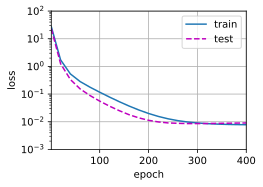

In [7]:
# 从多项式特征中选择前4个维度，即1, x, x^2/2!, x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

### 线性函数拟合（欠拟合）

weight:  [[3.6211948 3.7738361]]


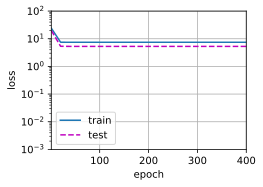

In [8]:
# 从多项式特征中选择前2个维度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

### 高阶多项式函数拟合（过拟合）

weight:  [[ 4.915291    1.2712597  -3.008093    5.1601763  -1.0147057   1.3144721
  -0.0958952  -0.04854358 -0.16526246  0.0178982   0.19936538  0.16839279
   0.12823373  0.1526359  -0.17954521  0.08657856  0.08291362 -0.02815451
   0.14615786 -0.13296038]]


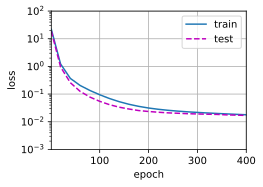

In [9]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:])

In [19]:
features = [[1], [2], [3], [4], [5]]
features
# poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
# for i in range(max_degree):
#     poly_features[:, i] /= math.gamma(i + 1)

[[1], [2], [3], [4], [5]]

In [22]:
np.arange(4).reshape(1, -1)

array([[0, 1, 2, 3]])

In [20]:
poly_features = np.power(features, np.arange(4).reshape(1, -1))
poly_features

array([[  1,   1,   1,   1],
       [  1,   2,   4,   8],
       [  1,   3,   9,  27],
       [  1,   4,  16,  64],
       [  1,   5,  25, 125]])